# Proyek Analisis Data: E-Commerce Public Dataset (Olist)
- **Nama:** [Isi nama Anda]
- **Email:** [Isi email Anda]
- **ID Dicoding:** [Isi ID Dicoding Anda]

## Menentukan Pertanyaan Bisnis

**Konteks.** Dataset berisi transaksi marketplace **Olist** di Brasil: pesanan, barang, pembayaran, ulasan, pelanggan, penjual, produk, dan lokasi. Bayangkan kita tim analis marketplace yang perlu menentukan **kategori mana yang diprioritaskan, bagaimana pertumbuhan penjualan, dan di wilayah mana pengiriman perlu diperbaiki**. Analisis memakai pesanan berstatus *delivered* pada **Januari 2017 – Agustus 2018**, yaitu 20 bulan dengan data lengkap (2016 dan September–Oktober 2018 hanya berisi segelintir pesanan). *Revenue* didefinisikan sebagai jumlah harga barang (`price`) tanpa ongkos kirim.

Pertanyaan bisnis (disusun dengan metode SMART):

1. **Kategori.** Kategori produk apa yang menghasilkan *revenue* tertinggi dan terendah (lima teratas dan lima terbawah) pada pesanan *delivered* selama Januari 2017 – Agustus 2018, dan berapa persen kontribusi lima kategori teratas terhadap total *revenue*?
   *Aksi:* menentukan kategori prioritas untuk stok, promosi, dan akuisisi penjual.
2. **Tren.** Bagaimana tren jumlah pesanan dan *revenue* bulanan selama Januari 2017 – Agustus 2018, dan berapa persen pertumbuhan *year-over-year* pada periode Januari–Agustus 2018 dibanding Januari–Agustus 2017?
   *Aksi:* merencanakan kapasitas logistik dan kalender kampanye.
3. **Wilayah dan pengiriman.** Di *state* mana pelanggan paling banyak, *state* mana yang memiliki rata-rata waktu pengiriman terlama dan *review score* terendah, dan berapa selisih *review score* antara pesanan tepat waktu dan terlambat, selama Januari 2017 – Agustus 2018?
   *Aksi:* memprioritaskan perbaikan logistik dan lokasi gudang di wilayah bermasalah.

## Import Semua Packages/Library yang Digunakan

In [1]:
import unicodedata
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

MONTHS = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]

def idn(x, decimals=0):
    """Format a number with Indonesian separators, e.g. 1.234,5."""
    return f"{x:,.{decimals}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Design tokens: gray for context, one color per meaning
GRAY, BLUE, RED, GREEN, ORANGE = "#B8BEC7", "#2F5D8C", "#C0392B", "#2E8B6B", "#E8833A"
INK, MUTED = "#2B2F36", "#5B6270"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "text.color": INK,
    "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E8EAEE", "axes.axisbelow": True,
})

## Data Wrangling

### Gathering Data
Dataset terdiri dari sembilan tabel CSV. Semuanya dibaca menjadi DataFrame; `geolocation_dataset` berukuran besar (±1 juta baris) sehingga disimpan terkompresi (`.csv.gz`) dan tetap dapat dibaca langsung oleh `pandas`.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")

customers = pd.read_csv(DATA_DIR / "customers_dataset.csv")
geolocation = pd.read_csv(DATA_DIR / "geolocation_dataset.csv.gz")
order_items = pd.read_csv(DATA_DIR / "order_items_dataset.csv")
payments = pd.read_csv(DATA_DIR / "order_payments_dataset.csv")
reviews = pd.read_csv(DATA_DIR / "order_reviews_dataset.csv")
orders = pd.read_csv(DATA_DIR / "orders_dataset.csv")
products = pd.read_csv(DATA_DIR / "products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "sellers_dataset.csv")
translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

tables = {"customers": customers, "geolocation": geolocation, "order_items": order_items, "order_payments": payments,
          "order_reviews": reviews, "orders": orders, "products": products, "sellers": sellers,
          "category_translation": translation}
overview = pd.DataFrame({name: {"rows": len(t), "columns": t.shape[1]} for name, t in tables.items()}).T
display(overview)
orders.head()

,rows,columns
customers,99441,5
geolocation,1000163,5
order_items,112650,7
order_payments,103886,5
order_reviews,99224,7
orders,99441,8
products,32951,9
sellers,3095,4
category_translation,71,2


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight (Gathering Data):**
- Terdapat **9 tabel** dengan total 1.550.922 baris; yang terbesar adalah `geolocation` (1.000.163 baris), lalu `order_items` (112.650) dan `order_payments` (103.886).
- Relasi utama: `orders` ↔ `customers` lewat `customer_id`; `orders` ↔ `order_items`, `order_payments`, `order_reviews` lewat `order_id`; `order_items` ↔ `products` dan `sellers`; `products` ↔ `category_translation` lewat nama kategori; lokasi diperoleh dari `geolocation` lewat kode pos (*zip code prefix*).
- `orders` berisi **99.441 pesanan**, sedangkan `order_items` berisi 112.650 baris karena satu pesanan dapat memuat beberapa barang.

### Assessing Data
Kualitas data dinilai pada seluruh tabel: *missing value*, duplikasi, tipe data, konsistensi status dan tanggal, nilai tidak valid, label yang tidak konsisten, cakupan waktu, dan *outlier*.

In [4]:
# Missing values and exact duplicate rows in every table
missing = pd.concat({k: t.isna().sum()[t.isna().sum() > 0] for k, t in tables.items() if t.isna().any().any()},
                    names=["table", "column"]).rename("missing").to_frame()
missing["pct"] = missing["missing"] / [len(tables[t]) for t, _ in missing.index] * 100
dups = pd.Series({k: int(t.duplicated().sum()) for k, t in tables.items()}, name="duplicate rows")
display(missing)
dups[dups > 0].to_frame().T

missing   pct
table         column                                      
order_reviews review_comment_title             87656 88.34
              review_comment_message           58247 58.70
orders        order_approved_at                  160  0.16
              order_delivered_carrier_date      1783  1.79
              order_delivered_customer_date     2965  2.98
products      product_category_name              610  1.85
              product_name_lenght                610  1.85
              product_description_lenght         610  1.85
              product_photos_qty                 610  1.85
              product_weight_g                     2  0.01
              product_length_cm                    2  0.01
              product_height_cm                    2  0.01
              product_width_cm                     2  0.01

,geolocation
duplicate rows,261831


In [5]:
# Order status, dates and consistency (dates are still plain text at this point)
DATE_COLS = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]
o = orders.copy()
o[DATE_COLS] = o[DATE_COLS].apply(pd.to_datetime)

status = o["order_status"].value_counts()
n_delivered_nodate = int(((o["order_status"] == "delivered") & o["order_delivered_customer_date"].isna()).sum())
n_other_withdate = int(((o["order_status"] != "delivered") & o["order_delivered_customer_date"].notna()).sum())
n_before_carrier = int((o["order_delivered_customer_date"] < o["order_delivered_carrier_date"]).sum())

monthly_orders = o.set_index("order_purchase_timestamp").resample("MS").size()
full_months = monthly_orders[(monthly_orders.index >= "2017-01-01") & (monthly_orders.index <= "2018-08-01")]
sparse_orders = int(monthly_orders.sum() - full_months.sum())
print(status.to_dict())
print(f"delivered without delivery date: {n_delivered_nodate} | other status with delivery date: {n_other_withdate} | delivered before carrier pickup: {n_before_carrier}")
print(f"first order {o['order_purchase_timestamp'].min():%Y-%m-%d}, last order {o['order_purchase_timestamp'].max():%Y-%m-%d}")
print(f"orders outside Jan 2017 - Aug 2018: {sparse_orders} | months in window: {len(full_months)} (min {full_months.min()}, max {full_months.max()} orders)")

{'delivered': 96478, 'shipped': 1107, 'canceled': 625, 'unavailable': 609, 'invoiced': 314, 'processing': 301, 'created': 5, 'approved': 2}
delivered without delivery date: 8 | other status with delivery date: 6 | delivered before carrier pickup: 23
first order 2016-09-04, last order 2018-10-17
orders outside Jan 2017 - Aug 2018: 349 | months in window: 20 (min 800, max 7544 orders)


In [6]:
# Reviews, customers, products and payments
n_review_dup_id = int(reviews["review_id"].duplicated().sum())
n_orders_multi_review = int((reviews["order_id"].value_counts() > 1).sum())
n_unique_cust, n_cust_rows = customers["customer_unique_id"].nunique(), len(customers)

n_cat_missing = int(products["product_category_name"].isna().sum())
untranslated = sorted(set(products["product_category_name"].dropna()) - set(translation["product_category_name"]))
n_zero_weight = int((products["product_weight_g"] == 0).sum())

n_pay_undefined = int((payments["payment_type"] == "not_defined").sum())
n_pay_zero = int((payments["payment_value"] == 0).sum())
pay_total = payments.groupby("order_id")["payment_value"].sum()
item_total = order_items.groupby("order_id")[["price", "freight_value"]].sum().sum(axis=1)
common = pay_total.index.intersection(item_total.index)
pay_ratio = pay_total[common].sum() / item_total[common].sum()
print(f"review_id duplicated: {n_review_dup_id} rows | orders with >1 review: {n_orders_multi_review}")
print(f"customer_id rows {n_cust_rows:,} vs unique people {n_unique_cust:,}")
print(f"products without category: {n_cat_missing} | categories missing from translation: {untranslated} | weight == 0: {n_zero_weight}")
print(f"payment_type not_defined: {n_pay_undefined} | payment_value == 0: {n_pay_zero} | payments / (price + freight): {pay_ratio:.3f}")

review_id duplicated: 814 rows | orders with >1 review: 547
customer_id rows 99,441 vs unique people 96,096
products without category: 610 | categories missing from translation: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'] | weight == 0: 4
payment_type not_defined: 3 | payment_value == 0: 9 | payments / (price + freight): 1.000


In [7]:
# Geolocation: duplicates, impossible coordinates and inconsistent city spelling
BR_LAT, BR_LNG = (-34.0, 6.0), (-74.0, -34.0)  # rough bounding box of Brazil
geo_out = ~geolocation["geolocation_lat"].between(*BR_LAT) | ~geolocation["geolocation_lng"].between(*BR_LNG)
n_geo_out, n_geo_dup = int(geo_out.sum()), int(geolocation.duplicated().sum())
n_geo_zip = geolocation["geolocation_zip_code_prefix"].nunique()

def strip_accents(s):
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode()

cities = pd.Series(geolocation["geolocation_city"].unique())
n_city_raw, n_city_norm = len(cities), cities.map(strip_accents).str.lower().nunique()
n_cust_nogeo = int((~customers["customer_zip_code_prefix"].isin(geolocation["geolocation_zip_code_prefix"])).sum())
print(f"geolocation rows {len(geolocation):,} | duplicates {n_geo_dup:,} | unique zip prefixes {n_geo_zip:,}")
print(f"coordinates outside Brazil: {n_geo_out} | city spellings {n_city_raw:,} -> {n_city_norm:,} after removing accents/case")
print(f"customers whose zip prefix is absent from geolocation: {n_cust_nogeo}")

geolocation rows 1,000,163 | duplicates 261,831 | unique zip prefixes 19,015
coordinates outside Brazil: 42 | city spellings 8,011 -> 5,968 after removing accents/case
customers whose zip prefix is absent from geolocation: 278


In [8]:
# Outliers: item price, freight and delivery time
q1, q3 = order_items["price"].quantile([0.25, 0.75])
price_fence = q3 + 1.5 * (q3 - q1)
pct_price_out = (order_items["price"] > price_fence).mean() * 100
price_max, price_median = order_items["price"].max(), order_items["price"].median()
freight_max = order_items["freight_value"].max()

dd = (o["order_delivered_customer_date"] - o["order_purchase_timestamp"]).dt.total_seconds() / 86400
d1, d3 = dd.quantile([0.25, 0.75])
pct_dd_out = (dd > d3 + 1.5 * (d3 - d1)).sum() / dd.notna().sum() * 100
dd_max, dd_median = dd.max(), dd.median()
print(f"price: median {price_median:.1f}, max {price_max:,.0f}, {pct_price_out:.1f}% above IQR fence {price_fence:.0f}; freight max {freight_max:.0f}")
print(f"delivery days: median {dd_median:.1f}, max {dd_max:.0f}, {pct_dd_out:.1f}% above IQR fence")

price: median 75.0, max 6,735, 7.5% above IQR fence 277; freight max 410
delivery days: median 10.2, max 210, 5.1% above IQR fence


**Insight (Assessing Data):** ditemukan sembilan kelompok temuan beserta tindakannya.

| # | Masalah | Temuan | Tindakan pada Cleaning Data |
|---|---------|--------|-----------------------------|
| 1 | *Missing value* | `orders`: tanggal disetujui (160), diserahkan ke kurir (1.783), dan diterima pelanggan (2.965) kosong untuk pesanan yang belum selesai. `products`: 610 produk tanpa kategori. `order_reviews`: judul (88%) dan isi komentar (59%) sering kosong. | Pakai hanya pesanan *delivered* bertanggal valid; kategori kosong diberi label `unknown`; komentar tidak dipakai. |
| 2 | Tipe data | Seluruh kolom tanggal pada `orders` bertipe teks. | Konversi ke `datetime`. |
| 3 | Duplikasi | `geolocation` memiliki 261.831 baris duplikat (19.015 kode pos unik dari 1.000.163 baris). `review_id` berulang pada 814 baris dan 547 pesanan memiliki lebih dari satu ulasan. | Ringkas `geolocation` menjadi satu titik per kode pos; ambil ulasan terbaru per pesanan. |
| 4 | *Inconsistent value*: status vs tanggal | 8 pesanan *delivered* tanpa tanggal terima, 6 pesanan non-*delivered* justru bertanggal terima, dan 23 pesanan diterima sebelum diserahkan ke kurir. | Hanya pesanan *delivered* dengan tanggal terima yang dipakai. |
| 5 | *Invalid value* | 42 koordinat berada di luar Brasil; `payment_type` = `not_defined` (3); `payment_value` = 0 (9); berat produk 0 (4). | Koordinat tidak valid dibuang; kolom pembayaran dan berat tidak dipakai pada analisis. |
| 6 | Label tidak konsisten | Nama kategori berbahasa Portugis dan 2 kategori tidak ada di tabel terjemahan (pc_gamer, portateis_cozinha_e_preparadores_de_alimentos); nama kota ditulis dengan/ tanpa aksen (8.011 ejaan menjadi 5.968 setelah dinormalisasi). | Terjemahkan ke Inggris dan lengkapi dua kategori secara manual; analisis wilayah memakai kode *state*, bukan nama kota. |
| 7 | Semantik ID | `customer_id` unik per pesanan (99.441 baris), sedangkan orang yang sama diwakili `customer_unique_id` (96.096 orang). | Hitung pelanggan dan RFM memakai `customer_unique_id`. |
| 8 | Cakupan waktu | Pesanan berlangsung Sep 2016 – Okt 2018, tetapi hanya 349 pesanan berada di luar Januari 2017 – Agustus 2018 (bulan lengkap berisi 800–7.544 pesanan). | Batasi analisis pada Januari 2017 – Agustus 2018. |
| 9 | *Outlier* | Harga barang median 75 tetapi maksimum 6.735 (7.5% di atas batas IQR); waktu pengiriman median 10.2 hari tetapi maksimum 210 hari. Total pembayaran mencapai 100.0% dari jumlah harga + ongkir, sehingga data harga konsisten dengan pembayaran. | Dipertahankan karena transaksi nyata; pengiriman dilengkapi median. |

### Cleaning Data
Langkah pembersihan mengikuti temuan pada Assessing Data:
1. Ubah kolom tanggal menjadi `datetime` dan hitung `delivery_days` serta `is_late` (diterima setelah estimasi).
2. Pilih pesanan *delivered* bertanggal valid pada **Januari 2017 – Agustus 2018**.
3. Ambil satu ulasan terbaru per pesanan.
4. Terjemahkan kategori ke bahasa Inggris (dua kategori dilengkapi manual, kategori kosong menjadi `unknown`).
5. Ringkas `geolocation` menjadi satu titik (median) per kode pos setelah koordinat tidak valid dibuang, lalu hubungkan ke pelanggan dan penjual.
6. Kelompokkan *state* ke lima wilayah Brasil (manual grouping) dan hitung jarak penjual–pelanggan.
7. Gabungkan semua tabel menjadi `sales` (satu baris per barang) dan `orders_level` (satu baris per pesanan), lalu simpan `dashboard/main_data.csv`.

In [9]:
START, END = pd.Timestamp("2017-01-01"), pd.Timestamp("2018-08-31 23:59:59")
REGION = {**dict.fromkeys(["AC", "AP", "AM", "PA", "RO", "RR", "TO"], "Norte"),
          **dict.fromkeys(["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"], "Nordeste"),
          **dict.fromkeys(["DF", "GO", "MT", "MS"], "Centro-Oeste"),
          **dict.fromkeys(["ES", "MG", "RJ", "SP"], "Sudeste"),
          **dict.fromkeys(["PR", "RS", "SC"], "Sul")}

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

# 1-2) Dates and the analysis window: delivered orders with a valid delivery date
orders[DATE_COLS] = orders[DATE_COLS].apply(pd.to_datetime)
keep = ((orders["order_status"] == "delivered") & orders["order_delivered_customer_date"].notna()
        & orders["order_purchase_timestamp"].between(START, END))
orders_ok = orders.loc[keep].copy()
orders_ok["delivery_days"] = (orders_ok["order_delivered_customer_date"] - orders_ok["order_purchase_timestamp"]).dt.total_seconds() / 86400
orders_ok["is_late"] = (orders_ok["order_delivered_customer_date"] > orders_ok["order_estimated_delivery_date"]).astype(int)

# 3) One review per order: keep the latest
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])
review_order = (reviews.sort_values("review_answer_timestamp").drop_duplicates("order_id", keep="last")
                [["order_id", "review_score"]])

# 4) Category in English
cat_map = dict(zip(translation["product_category_name"], translation["product_category_name_english"]))
cat_map.update({"pc_gamer": "pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_preparers"})
products["category"] = products["product_category_name"].map(cat_map).fillna("unknown")

# 5) One coordinate per zip prefix (median), after dropping impossible coordinates
zip_geo = (geolocation.loc[~geo_out].groupby("geolocation_zip_code_prefix")
           .agg(lat=("geolocation_lat", "median"), lng=("geolocation_lng", "median")))
customers = customers.join(zip_geo, on="customer_zip_code_prefix").rename(columns={"lat": "customer_lat", "lng": "customer_lng"})
sellers = sellers.join(zip_geo, on="seller_zip_code_prefix").rename(columns={"lat": "seller_lat", "lng": "seller_lng"})

# 6) Region grouping
customers["region"] = customers["customer_state"].map(REGION)

# 7) Item-level table
sales = (order_items.merge(orders_ok[["order_id", "customer_id", "order_purchase_timestamp", "delivery_days", "is_late"]], on="order_id")
         .merge(customers[["customer_id", "customer_unique_id", "customer_state", "region", "customer_lat", "customer_lng"]], on="customer_id")
         .merge(products[["product_id", "category"]], on="product_id", how="left")
         .merge(review_order, on="order_id", how="left")
         .merge(sellers[["seller_id", "seller_state", "seller_lat", "seller_lng"]], on="seller_id", how="left"))
sales["category"] = sales["category"].fillna("unknown")
sales["purchase_date"] = sales["order_purchase_timestamp"].dt.normalize()
sales["distance_km"] = haversine_km(sales["seller_lat"], sales["seller_lng"], sales["customer_lat"], sales["customer_lng"])

# Order-level table (one row per order) for trends, regions, satisfaction and RFM
orders_level = (sales.groupby("order_id")
                .agg(customer_unique_id=("customer_unique_id", "first"), purchase_date=("purchase_date", "first"),
                     customer_state=("customer_state", "first"), region=("region", "first"),
                     revenue=("price", "sum"), freight=("freight_value", "sum"), items=("price", "size"),
                     review_score=("review_score", "first"), delivery_days=("delivery_days", "first"),
                     is_late=("is_late", "first"), distance_km=("distance_km", "mean"),
                     customer_lat=("customer_lat", "first"), customer_lng=("customer_lng", "first"))
                .reset_index())
orders_level["month"] = orders_level["purchase_date"].dt.to_period("M").dt.to_timestamp()

n_orders_all, n_orders_ok = len(orders), len(orders_ok)
n_unknown_items = int((sales["category"] == "unknown").sum())
n_noreview = int(orders_level["review_score"].isna().sum())
n_nodist = int(orders_level["distance_km"].isna().sum())
total_revenue = sales["price"].sum()
print(f"orders {n_orders_all:,} -> {n_orders_ok:,} | items {len(sales):,} | customers {orders_level['customer_unique_id'].nunique():,} | revenue {total_revenue:,.0f}")
sales.head()

orders 99,441 -> 96,203 | items 109,872 | customers 93,096 | revenue 13,179,778


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_purchase_timestamp,delivery_days,is_late,customer_unique_id,customer_state,region,customer_lat,customer_lng,category,review_score,seller_state,seller_lat,seller_lng,purchase_date,distance_km
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,7.61,0,871766c5855e863f6eccc05f988b23cb,RJ,Sudeste,-21.76,-41.31,cool_stuff,5.00,SP,-22.50,-44.13,2017-09-13,301.23
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,16.22,0,eb28e67c4c0b83846050ddfb8a35d051,SP,Sudeste,-20.21,-50.93,pet_shop,4.00,SP,-23.56,-46.52,2017-04-26,588.40
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,7.95,0,3818d81c6709e39d06b2738a8d3a2474,MG,Sudeste,-19.87,-44.59,furniture_decor,5.00,MG,-22.27,-46.17,2018-01-14,312.84
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,6.15,0,af861d436cfc08b2c2ddefd0ba074622,SP,Sudeste,-23.10,-46.60,perfumery,4.00,SP,-20.55,-47.39,2018-08-08,295.03
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,25.11,0,64b576fb70d441e8f1b2d7d446e483c5,SP,Sudeste,-23.25,-46.83,garden_tools,5.00,PR,-22.93,-53.14,2017-02-04,646.47


In [10]:
# Export the cleaned item-level data for the Streamlit dashboard (short integer IDs keep the file small)
export = sales.assign(order_no=pd.factorize(sales["order_id"])[0] + 1,
                      customer_no=pd.factorize(sales["customer_unique_id"])[0] + 1)
export = export[["order_no", "customer_no", "purchase_date", "customer_state", "category", "price", "freight_value",
                 "review_score", "delivery_days", "is_late", "customer_lat", "customer_lng", "distance_km"]]
export = export.round({"delivery_days": 1, "customer_lat": 2, "customer_lng": 2, "distance_km": 0})
out_dir = DATA_DIR.parent / "dashboard"
out_dir.mkdir(exist_ok=True)
export.to_csv(out_dir / "main_data.csv", index=False, date_format="%Y-%m-%d")
print(f"{out_dir / 'main_data.csv'} saved: {len(export):,} rows x {export.shape[1]} columns")

dashboard/main_data.csv saved: 109,872 rows x 13 columns


**Insight (Cleaning Data):**
- Dari 99.441 pesanan, **96.203 pesanan** (96.7%) lolos filter *delivered* bertanggal valid pada Januari 2017 – Agustus 2018; datanya menjadi **109.872 baris barang** dari **93.096 pelanggan unik** dengan total *revenue* **R$ 13.179.778**.
- Kategori kosong kini berlabel `unknown` (1.535 barang, 1.4%) dan semua kategori telah diterjemahkan; 643 pesanan tanpa ulasan dan 477 pesanan tanpa koordinat (jarak) tetap dipakai pada analisis yang tidak memerlukannya.
- `geolocation` diringkas dari 1.000.163 baris menjadi **19.010 titik kode pos**; koordinat tidak valid (42) sudah dibuang.
- Data bersih disimpan sebagai `dashboard/main_data.csv` (satu baris per barang, ID dipendekkan menjadi angka) untuk dashboard.

## Exploratory Data Analysis (EDA)
Eksplorasi memakai tabel hasil pembersihan: `sales` (satu baris per barang) untuk analisis kategori dan `orders_level` (satu baris per pesanan) untuk tren, wilayah, dan kepuasan, sehingga pesanan dengan banyak barang tidak dihitung ganda.

### Explore: Pertanyaan 1 (Kategori)

In [11]:
def pretty(name):
    """Readable category label."""
    return name.replace("_", " ").title()

cat_all = (sales.groupby("category").agg(revenue=("price", "sum"), items=("price", "size"), orders=("order_id", "nunique"))
           .sort_values("revenue", ascending=False))
cat_known = cat_all.drop(index="unknown", errors="ignore").copy()   # 'unknown' is not a real category
cat_known["share_pct"] = cat_known["revenue"] / total_revenue * 100
cat_known["cum_pct"] = cat_known["share_pct"].cumsum()
cat_known["avg_price"] = cat_known["revenue"] / cat_known["items"]

top5, bottom5 = cat_known.head(5), cat_known.tail(5)
top5_share = top5["share_pct"].sum()
top10_share = cat_known["share_pct"].head(10).sum()
n_cat_80 = int((cat_known["cum_pct"] < 80).sum()) + 1
bottom5_share = bottom5["share_pct"].sum()
display(top5.round(1))
bottom5.round(1)

,revenue,items,orders,share_pct,cum_pct,avg_price
category,,,,,,
health_beauty,"1,229,557.50",9422,8610,9.30,9.30,130.50
watches_gifts,"1,163,187.90",5853,5489,8.80,18.20,198.70
bed_bath_table,"1,022,955.80",10945,9267,7.80,25.90,93.50
sports_leisure,"952,661.40",8413,7512,7.20,33.10,113.20
computers_accessories,"887,944.60",7631,6517,6.70,39.90,116.40


,revenue,items,orders,share_pct,cum_pct,avg_price
category,,,,,,
flowers,"1,110.00",33,29,0.00,98.70,33.60
home_comfort_2,760.30,30,24,0.00,98.70,25.30
cds_dvds_musicals,730.00,14,12,0.00,98.70,52.10
fashion_childrens_clothes,520.00,7,7,0.00,98.70,74.30
security_and_services,283.30,2,2,0.00,98.70,141.60


**Insight (EDA, Pertanyaan 1):**
- Lima kategori teratas: **Health Beauty** (R$ 1,23 juta), **Watches Gifts** (R$ 1,16 juta), **Bed Bath Table** (R$ 1,02 juta), **Sports Leisure** (R$ 0,95 juta), **Computers Accessories** (R$ 0,89 juta). Kelimanya menyumbang **39.9%** dari total *revenue* R$ 13.179.778, dan sepuluh kategori teratas 62.5%.
- Hanya **18 dari 73 kategori** yang dibutuhkan untuk mencapai 80% *revenue*: penjualan sangat terkonsentrasi (pola Pareto).
- Lima kategori terbawah: Security And Services (R$ 283), Fashion Childrens Clothes (R$ 520), Cds Dvds Musicals (R$ 730), Home Comfort 2 (R$ 760), Flowers (R$ 1.110); gabungannya hanya 0.03% dari *revenue*.
- Rata-rata harga barang berbeda jauh antar kategori (R$ 25–1.099 per barang), sehingga kategori dengan jumlah terjual besar tidak selalu menjadi penyumbang *revenue* terbesar.

### Explore: Pertanyaan 2 (Tren)

In [12]:
monthly = orders_level.groupby("month").agg(orders=("order_id", "size"), revenue=("revenue", "sum"))
peak_month = monthly["orders"].idxmax()
prev_month = peak_month - pd.DateOffset(months=1)
peak_jump = (monthly.loc[peak_month, "orders"] / monthly.loc[prev_month, "orders"] - 1) * 100

y17 = monthly[(monthly.index.year == 2017) & (monthly.index.month <= 8)].sum()   # Jan-Aug 2017
y18 = monthly[monthly.index.year == 2018].sum()                                   # Jan-Aug 2018
yoy_orders = (y18["orders"] / y17["orders"] - 1) * 100
yoy_revenue = (y18["revenue"] / y17["revenue"] - 1) * 100
aov17, aov18 = y17["revenue"] / y17["orders"], y18["revenue"] / y18["orders"]
def yoy_month(m):
    """Year-over-year change in orders for calendar month m (2018 vs 2017)."""
    return (monthly.loc[f"2018-{m:02d}-01", "orders"] / monthly.loc[f"2017-{m:02d}-01", "orders"] - 1) * 100
yoy_jan, yoy_jul, yoy_aug = yoy_month(1), yoy_month(7), yoy_month(8)

m18 = monthly.loc["2018-01-01":"2018-08-01", "orders"]
growth_2018 = (m18.iloc[-1] / m18.iloc[0] - 1) * 100
display(monthly.assign(revenue_juta=monthly["revenue"] / 1e6).drop(columns="revenue").round(2).T)

month,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01
orders,750.00,"1,653.00","2,546.00","2,303.00","3,545.00","3,135.00","3,872.00","4,193.00","4,150.00","4,478.00","7,288.00","5,513.00","7,069.00","6,555.00","7,003.00","6,798.00","6,749.00","6,096.00","6,156.00","6,351.00"
revenue_juta,0.11,0.23,0.36,0.34,0.49,0.42,0.48,0.55,0.61,0.65,0.99,0.73,0.92,0.83,0.95,0.97,0.98,0.86,0.87,0.84


**Insight (EDA, Pertanyaan 2):**
- Pesanan naik dari 750 (Jan 2017) hingga puncak **7.288 pada Nov 2017** (+63% dari bulan sebelumnya, bertepatan dengan periode *Black Friday*).
- Sepanjang 2018 pesanan bertahan pada kisaran 6.096–7.069 per bulan; Agustus 2018 berubah -10% dibanding Januari 2018, sehingga pertumbuhan bulanan **melandai**.
- Januari–Agustus 2018 dibanding Januari–Agustus 2017: pesanan **+139.9%** (21.997 → 52.777) dan *revenue* **+141.1%** (R$ 2,99 juta → R$ 7,22 juta). Nilai rata-rata per pesanan R$ 136,1 → R$ 136,7.
- Angka *year-over-year* sangat dipengaruhi **basis awal 2017 yang kecil**: pertumbuhan pesanan Januari +843%, tetapi melambat menjadi +59% (Juli) dan +51% (Agustus).

### Explore: Pertanyaan 3 (Wilayah dan Pengiriman)

In [13]:
state = (orders_level.groupby("customer_state")
         .agg(customers=("customer_unique_id", "nunique"), orders=("order_id", "size"), revenue=("revenue", "sum"),
              delivery_days=("delivery_days", "mean"), review=("review_score", "mean"), late_pct=("is_late", "mean")))
state["late_pct"] *= 100
state["cust_share"] = state["customers"] / state["customers"].sum() * 100
state = state.sort_values("customers", ascending=False)

MIN_ORDERS = 100  # states with fewer orders are too noisy to rank
big = state[state["orders"] >= MIN_ORDERS]
n_small = len(state) - len(big)
top_state, top5_state_share = state.index[0], state["cust_share"].head(5).sum()
slowest, fastest = big["delivery_days"].idxmax(), big["delivery_days"].idxmin()
lowest_score, highest_score = big["review"].idxmin(), big["review"].idxmax()

score_by_late = orders_level.groupby("is_late")["review_score"].mean()
late_share = orders_level["is_late"].mean() * 100
score_gap = score_by_late[0] - score_by_late[1]

DAY_BINS = [0, 7, 14, 21, np.inf]
DAY_LABELS = ["≤7 hari", "8–14 hari", "15–21 hari", ">21 hari"]
orders_level["delivery_bin"] = pd.cut(orders_level["delivery_days"], bins=DAY_BINS, labels=DAY_LABELS, include_lowest=True)
by_bin = orders_level.groupby("delivery_bin", observed=True).agg(orders=("order_id", "size"), review=("review_score", "mean"))
display(state.head(8).round(2))
big.sort_values("delivery_days").iloc[[0, 1, 2, -3, -2, -1]].round(2)

,customers,orders,revenue,delivery_days,review,late_pct,cust_share
customer_state,,,,,,,
SP,39058,40399,"5,054,516.95",8.74,4.25,5.90,41.94
RJ,11879,12310,"1,751,433.85",15.30,3.97,13.52,12.75
MG,10969,11319,"1,548,206.88",11.98,4.19,5.63,11.78
RS,5150,5327,"726,194.92",15.29,4.19,7.17,5.53
PR,4750,4903,"664,048.00",11.97,4.24,5.02,5.10
SC,3441,3537,"504,774.07",14.95,4.13,9.78,3.69
BA,3155,3253,"493,339.26",19.33,3.93,14.05,3.39
DF,2013,2074,"295,454.64",12.94,4.13,7.09,2.16


,customers,orders,revenue,delivery_days,review,late_pct,cust_share
customer_state,,,,,,,
SP,39058,40399,"5,054,516.95",8.74,4.25,5.90,41.94
PR,4750,4903,"664,048.00",11.97,4.24,5.02,5.10
MG,10969,11319,"1,548,206.88",11.98,4.19,5.63,11.78
PA,918,942,"173,382.99",23.76,3.91,12.42,0.99
AL,386,396,"78,805.73",24.52,3.85,23.99,0.41
AM,140,145,"22,155.84",26.43,4.24,4.14,0.15


**Insight (EDA, Pertanyaan 3):**
- Pelanggan paling banyak di **SP** (41.9% pelanggan); lima *state* teratas (SP, RJ, MG, RS, PR) mencakup **77.1%** pelanggan.
- Dari *state* dengan ≥ 100 pesanan (3 *state* kecil dikeluarkan dari peringkat), pengiriman tercepat di **SP** (8.7 hari) dan terlama di **AM** (26.4 hari), yaitu 3.0× lebih lama.
- *Review score* tertinggi di **SP** (4.25) dan terendah di **MA** (3.83); *state* dengan skor terendah memiliki 20% pesanan terlambat.
- Pesanan terlambat (**8.1%** dari seluruh pesanan) mendapat skor rata-rata **2.57**, sedangkan yang tepat waktu **4.29**: selisih **1.73 poin**. Skor turun bertahap seiring waktu kirim, dari 4.42 (≤7 hari) menjadi 3.12 (> 21 hari).

## Visualization & Explanatory Analysis
Setiap visualisasi mengikuti prinsip desain dan integritas grafis berikut:
- **Judul memuat pesan utama**; subjudul menjelaskan ukuran dan periode data; sumber data dicantumkan.
- **Warna untuk menekankan, bukan menghias**: abu-abu untuk konteks, hijau untuk nilai terbaik, merah untuk nilai terburuk, biru untuk fokus atau pembanding. Makna warna sama di semua grafik.
- **Sumbu nilai dimulai dari nol** pada grafik batang dan garis agar selisih visual sebanding dengan selisih data; satuan (R$ juta, R$ ribu, hari, %) selalu ditulis, dan perbedaan satuan antarpanel disebut eksplisit.
- **Label langsung** pada batang/garis, garis acuan, *gridline* tipis, tanpa bingkai atas/kanan agar tidak ada *chart junk*.
- **Ukuran sampel (*n*)** ditampilkan ketika kelompok berbeda ukuran, dan *state* kecil dikeluarkan dari peringkat agar tidak menyesatkan.

In [14]:
SOURCE = "Sumber: Olist Brazilian E-Commerce Public Dataset, pesanan delivered Jan 2017 – Agu 2018"

def add_titles(fig, title, subtitle):
    """Left-aligned takeaway title, subtitle and source note."""
    fig.suptitle(title, x=0.01, y=0.985, ha="left", fontsize=13.5, fontweight="bold", color=INK)
    fig.text(0.01, 0.915, subtitle, ha="left", fontsize=9.5, color=MUTED)
    fig.text(0.01, 0.012, SOURCE, ha="left", fontsize=8, color=MUTED)

fmt_int = FuncFormatter(lambda v, _: idn(v))

### Pertanyaan 1: Kategori apa yang menghasilkan revenue terbesar dan terkecil?
*Kategori produk apa yang menghasilkan revenue tertinggi dan terendah (lima teratas dan lima terbawah) pada pesanan delivered selama Januari 2017 – Agustus 2018, dan berapa persen kontribusi lima kategori teratas terhadap total revenue?*

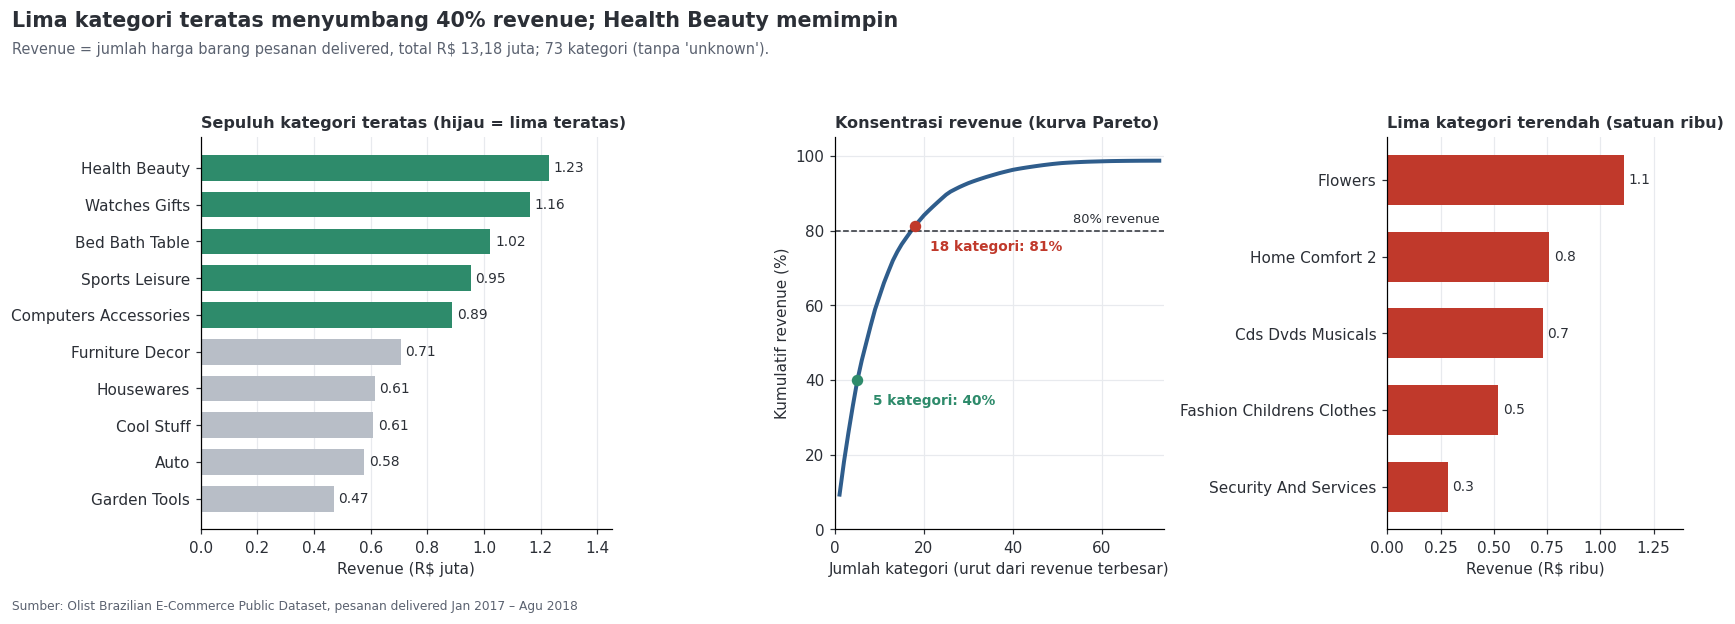

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.6), gridspec_kw={"width_ratios": [1.25, 1, 0.9]})

# Left: ten largest categories
ax = axes[0]
t10 = cat_known.head(10).iloc[::-1]
bars = ax.barh([pretty(c) for c in t10.index], t10["revenue"] / 1e6, color=[GREEN if i >= 5 else GRAY for i in range(10)], height=0.7)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.set_xlim(0, t10["revenue"].max() / 1e6 * 1.18)
ax.set_xlabel("Revenue (R$ juta)")
ax.set_title("Sepuluh kategori teratas (hijau = lima teratas)", fontsize=10.5)
ax.grid(axis="y", visible=False)

# Middle: Pareto curve
ax = axes[1]
rank = np.arange(1, len(cat_known) + 1)
ax.plot(rank, cat_known["cum_pct"], color=BLUE, lw=2.6)
ax.axhline(80, color=INK, ls="--", lw=1)
for k, color in [(5, GREEN), (n_cat_80, RED)]:
    y = cat_known["cum_pct"].iloc[k - 1]
    ax.scatter([k], [y], color=color, zorder=3, s=42)
    ax.annotate(f"{k} kategori: {y:.0f}%", (k, y), xytext=(10, -16), textcoords="offset points", fontsize=9, fontweight="bold", color=color)
ax.text(len(cat_known), 82, "80% revenue", ha="right", fontsize=8.5)
ax.set_xlim(0, len(cat_known) + 1)
ax.set_ylim(0, 105)
ax.set_xlabel("Jumlah kategori (urut dari revenue terbesar)")
ax.set_ylabel("Kumulatif revenue (%)")
ax.set_title("Konsentrasi revenue (kurva Pareto)", fontsize=10.5)

# Right: five smallest categories (note the different unit)
ax = axes[2]
b5 = bottom5.iloc[::-1]
bars = ax.barh([pretty(c) for c in b5.index], b5["revenue"] / 1e3, color=RED, height=0.65)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
ax.set_xlim(0, b5["revenue"].max() / 1e3 * 1.25)
ax.set_xlabel("Revenue (R$ ribu)")
ax.set_title("Lima kategori terendah (satuan ribu)", fontsize=10.5)
ax.grid(axis="y", visible=False)

add_titles(fig,
           f"Lima kategori teratas menyumbang {top5_share:.0f}% revenue; {pretty(cat_known.index[0])} memimpin",
           f"Revenue = jumlah harga barang pesanan delivered, total R$ {idn(total_revenue / 1e6, 2)} juta; {len(cat_known)} kategori (tanpa 'unknown').")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 1):**
- Grafik kiri: **Health Beauty** memimpin dengan R$ 1,23 juta (9.3% total), disusul Watches Gifts dan Bed Bath Table. Selisih antara peringkat pertama dan kelima menunjukkan tidak ada satu kategori yang mendominasi sendirian.
- Grafik tengah: kurva naik tajam di awal lalu mendatar; **lima kategori = 40%**, sepuluh kategori = 62%, dan **18 kategori** sudah mencapai 80%. Sisa 55 kategori hanya berbagi sekitar 20%.
- Grafik kanan: lima kategori terbawah bernilai R$ 283–1.110 (satuan ribu pada sumbu, bukan juta), atau 0.03% dari *revenue*; kategori-kategori ini niche dan tidak menggerakkan bisnis.

### Pertanyaan 2: Bagaimana tren pesanan dan revenue?
*Bagaimana tren jumlah pesanan dan revenue bulanan selama Januari 2017 – Agustus 2018, dan berapa persen pertumbuhan year-over-year pada periode Januari–Agustus 2018 dibanding Januari–Agustus 2017?*

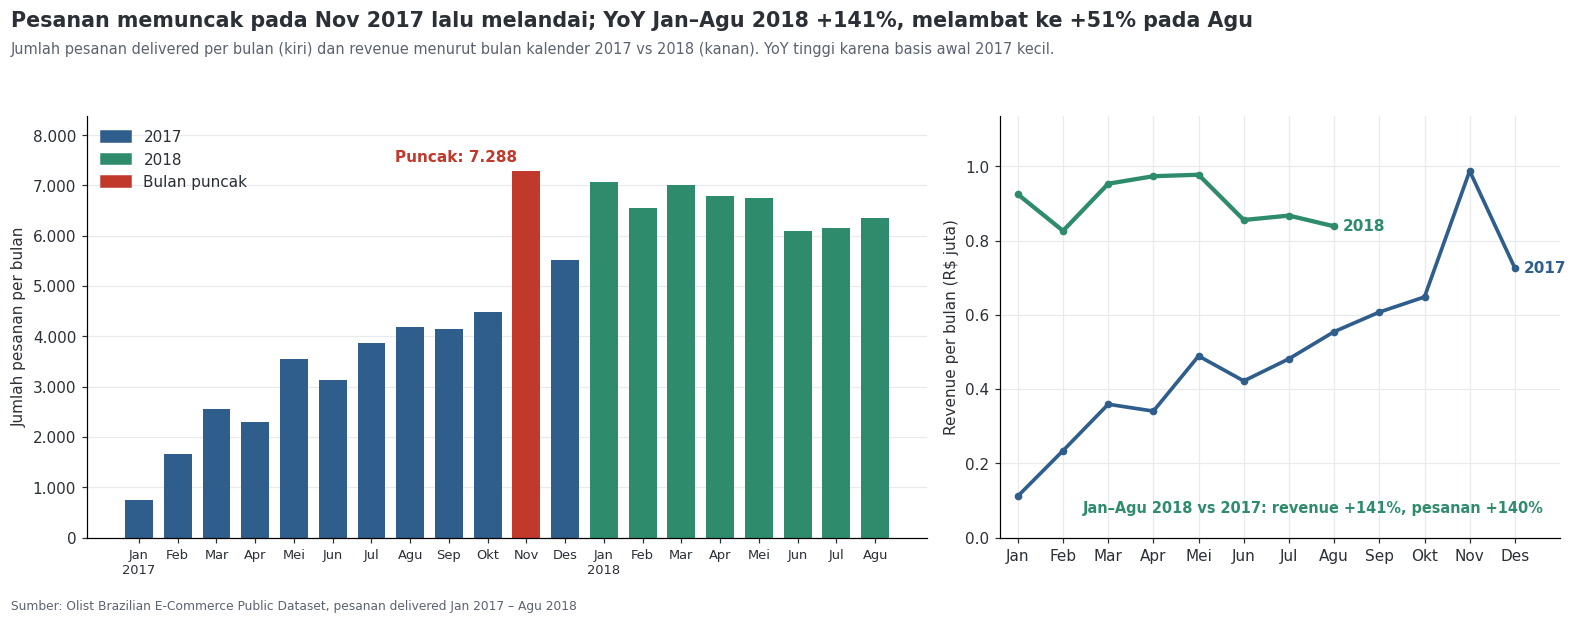

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={"width_ratios": [1.5, 1]})

# Left: monthly orders over the whole window
ax = axes[0]
x = np.arange(len(monthly))
colors = [RED if m == peak_month else BLUE if m.year == 2017 else GREEN for m in monthly.index]
ax.bar(x, monthly["orders"], color=colors, width=0.72)
ax.set_xticks(x, [f"{MONTHS[m.month - 1]}\n{m.year}" if (m.month == 1) else MONTHS[m.month - 1] for m in monthly.index], fontsize=8.5)
peak_x = list(monthly.index).index(peak_month)
ax.annotate(f"Puncak: {idn(monthly.loc[peak_month, 'orders'])}", (peak_x, monthly.loc[peak_month, "orders"]),
            xytext=(-6, 6), textcoords="offset points", ha="right", color=RED, fontweight="bold")
ax.yaxis.set_major_formatter(fmt_int)
ax.set_ylim(0, monthly["orders"].max() * 1.15)
ax.set_ylabel("Jumlah pesanan per bulan")
ax.grid(axis="x", visible=False)
ax.legend(handles=[Patch(color=BLUE, label="2017"), Patch(color=GREEN, label="2018"), Patch(color=RED, label="Bulan puncak")],
          frameon=False, loc="upper left")

# Right: revenue by calendar month, 2017 vs 2018
ax = axes[1]
rev = monthly["revenue"] / 1e6
for yr, color, lw in [(2017, BLUE, 2.4), (2018, GREEN, 2.8)]:
    s = rev[rev.index.year == yr]
    ax.plot(s.index.month, s.values, color=color, lw=lw, marker="o", ms=4)
    ax.text(s.index.month[-1] + 0.2, s.values[-1], str(yr), color=color, va="center", fontweight="bold")
ax.text(0.97, 0.06, f"Jan–Agu 2018 vs 2017: revenue {yoy_revenue:+.0f}%, pesanan {yoy_orders:+.0f}%", transform=ax.transAxes,
        ha="right", fontsize=9.5, fontweight="bold", color=GREEN)
ax.set_xticks(range(1, 13), MONTHS)
ax.set_xlim(0.6, 13)
ax.set_ylim(0, rev.max() * 1.15)
ax.set_ylabel("Revenue per bulan (R$ juta)")

add_titles(fig,
           f"Pesanan memuncak pada {MONTHS[peak_month.month - 1]} {peak_month.year} lalu melandai; YoY Jan–Agu 2018 {yoy_revenue:+.0f}%, melambat ke {yoy_aug:+.0f}% pada Agu",
           "Jumlah pesanan delivered per bulan (kiri) dan revenue menurut bulan kalender 2017 vs 2018 (kanan). YoY tinggi karena basis awal 2017 kecil.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 2):**
- Grafik kiri: pertumbuhan 2017 sangat cepat dari 750 pesanan (Jan) ke puncak 7.288 pada Nov 2017. Setelah itu level bertahan di sekitar 6.096–7.069 per bulan sepanjang 2018, tanpa lonjakan baru.
- Grafik kanan: kurva 2018 berada di atas kurva 2017 pada semua bulan yang tersedia, dengan jarak yang menyempit menjelang Agustus. Secara kumulatif Jan–Agu *revenue* naik **+141.1%** dan pesanan **+139.9%**; pertumbuhan *revenue* lebih tinggi daripada pesanan karena nilai rata-rata per pesanan bergerak dari R$ 136,1 ke R$ 136,7.
- Angka YoY yang besar sebagian merupakan efek basis rendah awal 2017: pertumbuhan pesanan +843% pada Januari mengecil menjadi **+51% pada Agustus**. Pertumbuhan 2018 terutama berasal dari **basis pesanan yang lebih besar**, bukan peningkatan bulanan yang berkelanjutan; dibutuhkan pemicu baru (kampanye, kategori, retensi) agar kurva kembali naik.

### Pertanyaan 3: Di mana pelanggan terkonsentrasi dan bagaimana pengirimannya?
*Di state mana pelanggan paling banyak, state mana yang memiliki rata-rata waktu pengiriman terlama dan review score terendah, dan berapa selisih review score antara pesanan tepat waktu dan terlambat, selama Januari 2017 – Agustus 2018?*

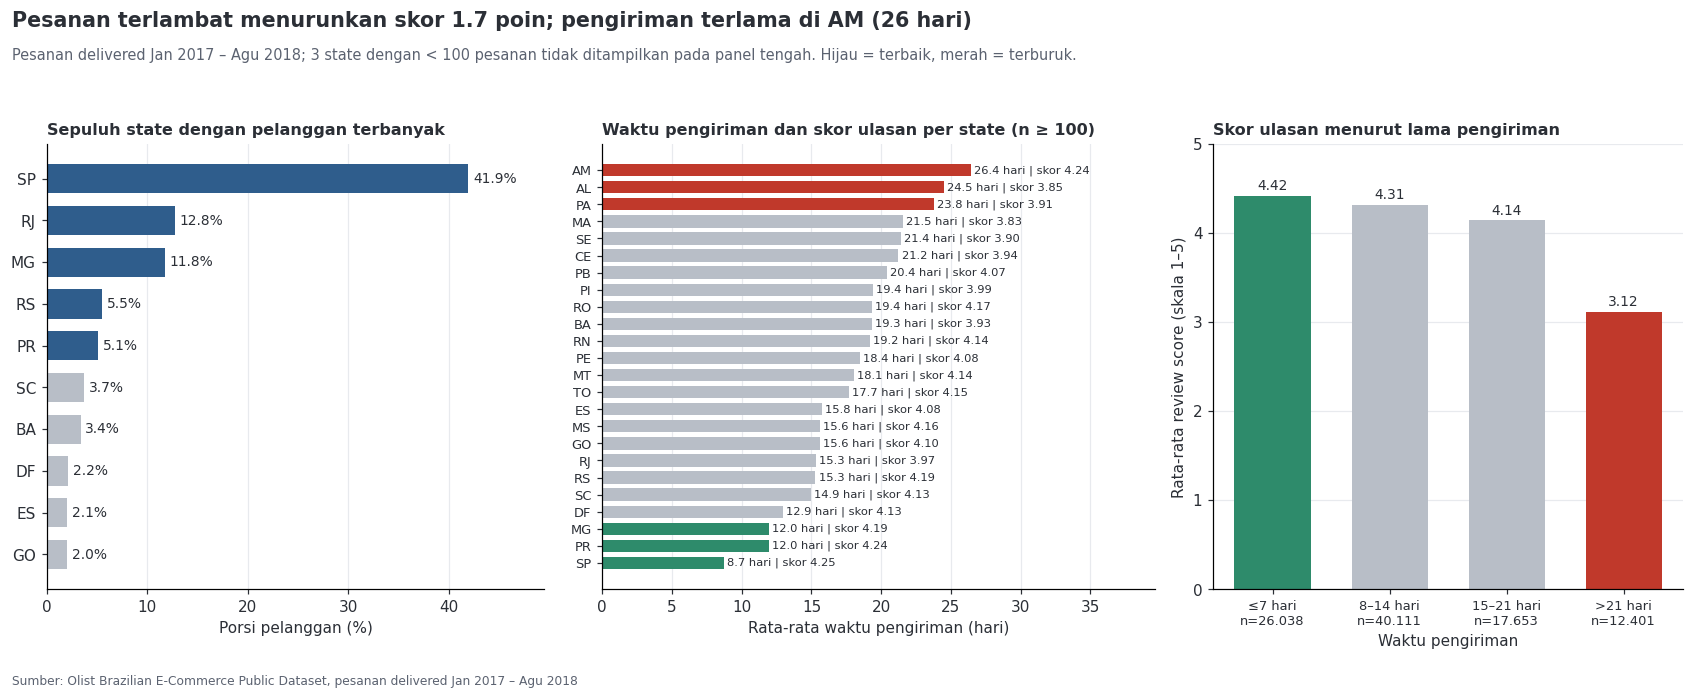

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 6.3), gridspec_kw={"width_ratios": [0.9, 1, 0.85]})

# Left: customer share of the ten largest states
ax = axes[0]
t10 = state.head(10).iloc[::-1]
bars = ax.barh(t10.index, t10["cust_share"], color=[BLUE if i >= 5 else GRAY for i in range(10)], height=0.7)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_xlim(0, t10["cust_share"].max() * 1.18)
ax.set_xlabel("Porsi pelanggan (%)")
ax.set_title("Sepuluh state dengan pelanggan terbanyak", fontsize=10.5)
ax.grid(axis="y", visible=False)

# Middle: mean delivery time per state (states with enough orders)
ax = axes[1]
b = big.sort_values("delivery_days")
colors = [GREEN if i < 3 else RED if i >= len(b) - 3 else GRAY for i in range(len(b))]
bars = ax.barh(b.index, b["delivery_days"], color=colors, height=0.72)
ax.bar_label(bars, labels=[f"{d:.1f} hari | skor {s:.2f}" for d, s in zip(b["delivery_days"], b["review"])], padding=2, fontsize=7.5)
ax.set_xlim(0, b["delivery_days"].max() * 1.5)
ax.set_xlabel("Rata-rata waktu pengiriman (hari)")
ax.set_title(f"Waktu pengiriman dan skor ulasan per state (n ≥ {MIN_ORDERS})", fontsize=10.5)
ax.tick_params(axis="y", labelsize=8.5)
ax.grid(axis="y", visible=False)

# Right: review score by delivery-time class
ax = axes[2]
r = by_bin["review"]
colors = [GREEN if v == r.max() else RED if v == r.min() else GRAY for v in r.values]
bars = ax.bar(range(len(r)), r.values, color=colors, width=0.65)
ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=9)
ax.set_xticks(range(len(r)), [f"{lab}\nn={idn(c)}" for lab, c in zip(r.index, by_bin["orders"])], fontsize=8.5)
ax.set_ylim(0, 5)
ax.set_ylabel("Rata-rata review score (skala 1–5)")
ax.set_xlabel("Waktu pengiriman")
ax.set_title("Skor ulasan menurut lama pengiriman", fontsize=10.5)
ax.grid(axis="x", visible=False)

add_titles(fig,
           f"Pesanan terlambat menurunkan skor {score_gap:.1f} poin; pengiriman terlama di {slowest} ({big.loc[slowest, 'delivery_days']:.0f} hari)",
           f"Pesanan delivered Jan 2017 – Agu 2018; {n_small} state dengan < {MIN_ORDERS} pesanan tidak ditampilkan pada panel tengah. "
           "Hijau = terbaik, merah = terburuk.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (Explanatory Analysis, Pertanyaan 3):**
- Grafik kiri: pelanggan sangat terpusat; **SP** sendiri 41.9% dan lima *state* teratas 77.1%, sehingga kualitas layanan di wilayah Tenggara/Selatan menentukan pengalaman mayoritas pelanggan.
- Grafik tengah: waktu pengiriman berkisar 8.7–26.4 hari; tiga *state* terlama (AM, AL, PA) berada jauh dari pusat penjual, sedangkan tiga tercepat (SP, PR, MG) berada di dekatnya.
- Grafik kanan: skor turun konsisten dari 4.42 (≤7 hari) ke 3.12 (> 21 hari). Pesanan terlambat (8.1%) rata-rata dinilai 2.57 vs 4.29 untuk yang tepat waktu: **keterlambatan adalah pendorong utama ulasan buruk**.

## Analisis Lanjutan: RFM, Geospatial Analysis, dan Manual Grouping

Tiga teknik berikut diterapkan **tanpa algoritma *machine learning***:

1. **RFM Analysis.** *Tujuan:* mengelompokkan pelanggan berdasarkan perilaku belanja: ***Recency*** (hari sejak pembelian terakhir terhadap 1 September 2018), ***Frequency*** (jumlah pesanan), dan ***Monetary*** (total belanja). Recency dan Monetary diberi skor 1–5 dengan kuintil (`pd.qcut`); karena hampir semua pelanggan hanya membeli sekali, Frequency tidak dikuintilkan melainkan dipakai sebagai aturan (≥ 2 pesanan = loyal). Segmen ditentukan dengan aturan bisnis sehingga langsung dapat ditindaklanjuti.
2. **Geospatial analysis.** *Tujuan:* melihat pola lokasi pelanggan dan penjual: peta kepadatan pelanggan, peta interaktif per *state* (`folium`), dan hubungan **jarak penjual–pelanggan** (rumus *haversine* dari koordinat kode pos) dengan waktu pengiriman dan beban ongkos kirim.
3. ***Manual grouping/binning*.** *Tujuan:* menyederhanakan data kontinu menjadi kelompok yang bermakna: 27 *state* dikelompokkan ke lima wilayah Brasil (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) dan jarak dibagi menjadi lima kelas (`pd.cut`).

> **Catatan:** koordinat berasal dari titik tengah (median) kode pos pada dataset `geolocation`, sehingga jarak bersifat perkiraan (garis lurus, bukan rute darat).

### RFM Analysis

In [18]:
SNAPSHOT = END.normalize() + pd.Timedelta(days=1)  # reference date: 1 Sep 2018
SEG = ["Loyal (repeat)", "Baru bernilai tinggi", "Baru reguler", "Berisiko bernilai tinggi", "Hibernasi"]

rfm = (orders_level.groupby("customer_unique_id")
       .agg(last_purchase=("purchase_date", "max"), frequency=("order_id", "nunique"), monetary=("revenue", "sum")))
rfm["recency"] = (SNAPSHOT - rfm["last_purchase"]).dt.days
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)                      # 5 = most recent
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)  # 5 = biggest spenders

# Rule-based segments (first matching rule wins)
rules = [rfm["frequency"] >= 2,
         (rfm["R"] >= 4) & (rfm["M"] >= 4),
         rfm["R"] >= 4,
         rfm["M"] >= 4]
rfm["segment"] = np.select(rules, SEG[:4], default=SEG[4])

seg = (rfm.groupby("segment").agg(customers=("monetary", "size"), revenue=("monetary", "sum"),
                                  avg_recency=("recency", "mean"), avg_spend=("monetary", "mean")).reindex(SEG))
seg["cust_pct"] = seg["customers"] / seg["customers"].sum() * 100
seg["rev_pct"] = seg["revenue"] / seg["revenue"].sum() * 100
repeat_pct = (rfm["frequency"] >= 2).mean() * 100
r_edges = rfm.groupby("R")["recency"].agg(["min", "max"])
m_edges = rfm.groupby("M")["monetary"].agg(["min", "max"])
display(rfm[["recency", "frequency", "monetary"]].describe().T.round(1))
seg.round(1)

,count,mean,std,min,25%,50%,75%,max
recency,"93,096.00",239.20,150.90,3.00,117.00,221.00,348.00,604.00
frequency,"93,096.00",1.00,0.20,1.00,1.00,1.00,1.00,15.00
monetary,"93,096.00",141.60,215.80,0.80,47.60,89.70,154.20,"13,440.00"


,customers,revenue,avg_recency,avg_spend,cust_pct,rev_pct
segment,,,,,,
Loyal (repeat),2789,"725,355.00",222.10,260.10,3.00,5.50
Baru bernilai tinggi,14473,"3,865,125.10",94.20,267.10,15.50,29.30
Baru reguler,21643,"1,201,427.70",92.10,55.50,23.20,9.10
Berisiko bernilai tinggi,20640,"5,521,130.10",336.70,267.50,22.20,41.90
Hibernasi,33551,"1,866,739.90",338.20,55.60,36.00,14.20


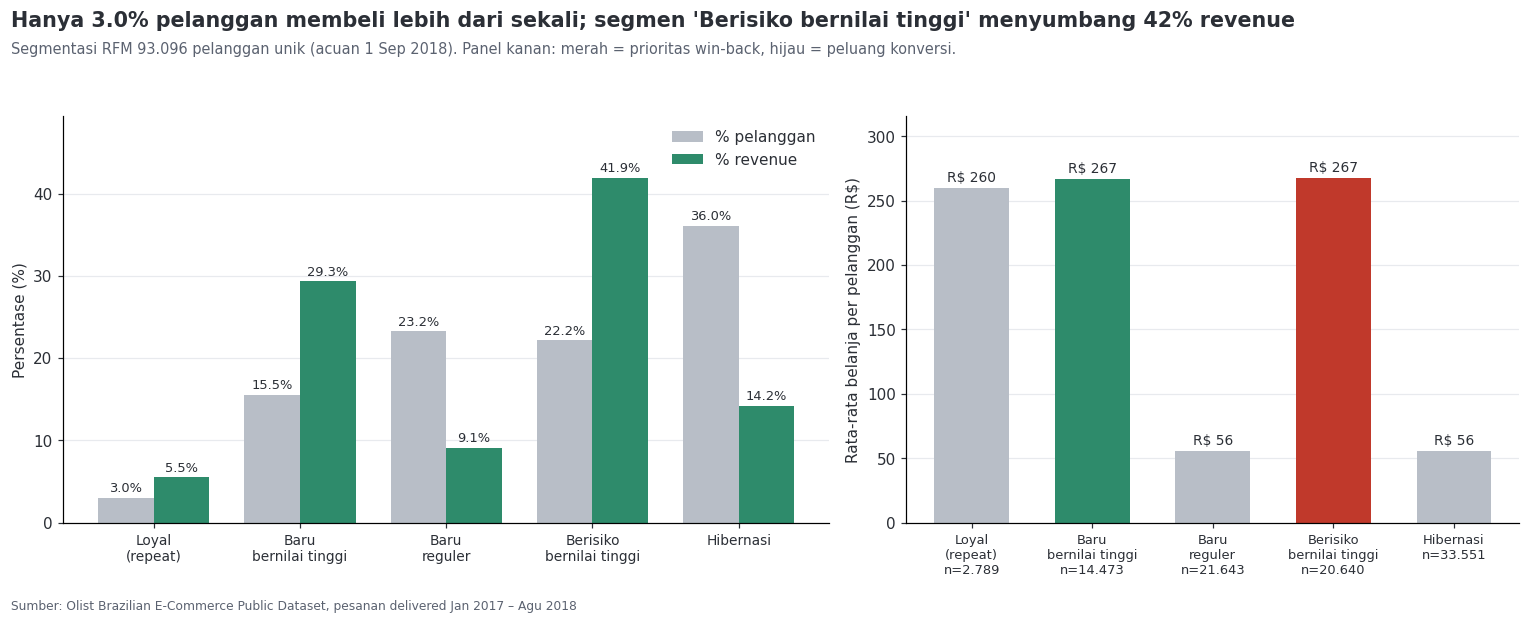

In [19]:
SEG_LABELS = ["Loyal\n(repeat)", "Baru\nbernilai tinggi", "Baru\nreguler", "Berisiko\nbernilai tinggi", "Hibernasi"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.25, 1]})

# Left: share of customers vs share of revenue
ax = axes[0]
x, w = np.arange(len(SEG)), 0.38
b1 = ax.bar(x - w / 2, seg["cust_pct"], w, color=GRAY, label="% pelanggan")
b2 = ax.bar(x + w / 2, seg["rev_pct"], w, color=GREEN, label="% revenue")
ax.bar_label(b1, fmt="%.1f%%", padding=2, fontsize=8.5)
ax.bar_label(b2, fmt="%.1f%%", padding=2, fontsize=8.5)
ax.set_xticks(x, SEG_LABELS, fontsize=9)
ax.set_ylim(0, max(seg["cust_pct"].max(), seg["rev_pct"].max()) * 1.18)
ax.set_ylabel("Persentase (%)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper right")

# Right: mean spend per customer
ax = axes[1]
colors = [RED if s == SEG[3] else GREEN if s == SEG[1] else GRAY for s in SEG]  # red = win-back priority, green = conversion chance
bars = ax.bar(x, seg["avg_spend"], color=colors, width=0.62)
ax.bar_label(bars, labels=[f"R$ {idn(v)}" for v in seg["avg_spend"]], padding=2, fontsize=9)
ax.set_xticks(x, [f"{lab}\nn={idn(c)}" for lab, c in zip(SEG_LABELS, seg["customers"])], fontsize=8.5)
ax.set_ylim(0, seg["avg_spend"].max() * 1.18)
ax.set_ylabel("Rata-rata belanja per pelanggan (R$)")
ax.grid(axis="x", visible=False)

add_titles(fig,
           f"Hanya {repeat_pct:.1f}% pelanggan membeli lebih dari sekali; segmen 'Berisiko bernilai tinggi' menyumbang {seg.loc[SEG[3], 'rev_pct']:.0f}% revenue",
           f"Segmentasi RFM {idn(len(rfm))} pelanggan unik (acuan 1 Sep 2018). Panel kanan: merah = prioritas win-back, hijau = peluang konversi.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

**Insight (RFM):**
- **Retensi sangat rendah:** hanya **3.0%** pelanggan (2.789 orang) yang membeli lebih dari sekali; **97.0%** hanya sekali bertransaksi. Karena Frequency hampir konstan, pembeda utama pelanggan adalah Recency dan Monetary.
- **Berisiko bernilai tinggi** (22.2% pelanggan) menyumbang **41.9% *revenue*** dengan rata-rata belanja R$ 267 dan sudah 337 hari tidak kembali: kelompok *win-back* paling bernilai.
- Skor **R = 5** berarti pembelian terakhir ≤ 94 hari sebelum acuan, dan **M = 5** berarti total belanja ≥ R$ 180 (kuintil teratas).
- **Baru bernilai tinggi** (15.5% pelanggan, 29.3% *revenue*, recency 94 hari) adalah peluang konversi menjadi pelanggan loyal sebelum mereka berpindah ke kelompok berisiko. **Hibernasi** (36.0% pelanggan) bernilai rendah dan lama tidak aktif.
- Pelanggan **loyal** hanya 3.0% tetapi menyumbang 5.5% *revenue* (rata-rata R$ 260 per orang): pembelian ulang bernilai besar.

### Geospatial Analysis dan Manual Grouping

In [20]:
region_tab = (orders_level.groupby("region")
              .agg(customers=("customer_unique_id", "nunique"), orders=("order_id", "size"), revenue=("revenue", "sum"),
                   delivery_days=("delivery_days", "mean"), review=("review_score", "mean"), late_pct=("is_late", "mean")))
region_tab["late_pct"] *= 100
region_tab["cust_share"] = region_tab["customers"] / region_tab["customers"].sum() * 100
region_tab = region_tab.sort_values("delivery_days")

geo_orders = orders_level.dropna(subset=["customer_lat", "customer_lng"])
state_xy = geo_orders.groupby("customer_state")[["customer_lat", "customer_lng"]].median()
fast_reg, slow_reg = region_tab.index[0], region_tab.index[-1]
display(region_tab.round(2))

,customers,orders,revenue,delivery_days,review,late_pct,cust_share
region,,,,,,,
Sudeste,63824,66020,"8,621,941.34",10.73,4.18,7.47,68.54
Sul,13338,13767,"1,895,016.99",14.02,4.19,7.07,14.32
Centro-Oeste,5436,5610,"844,960.64",15.01,4.13,7.99,5.84
Nordeste,8784,9015,"1,491,911.33",19.99,3.97,14.36,9.43
Norte,1737,1791,"325,947.65",22.59,4.03,9.83,1.87


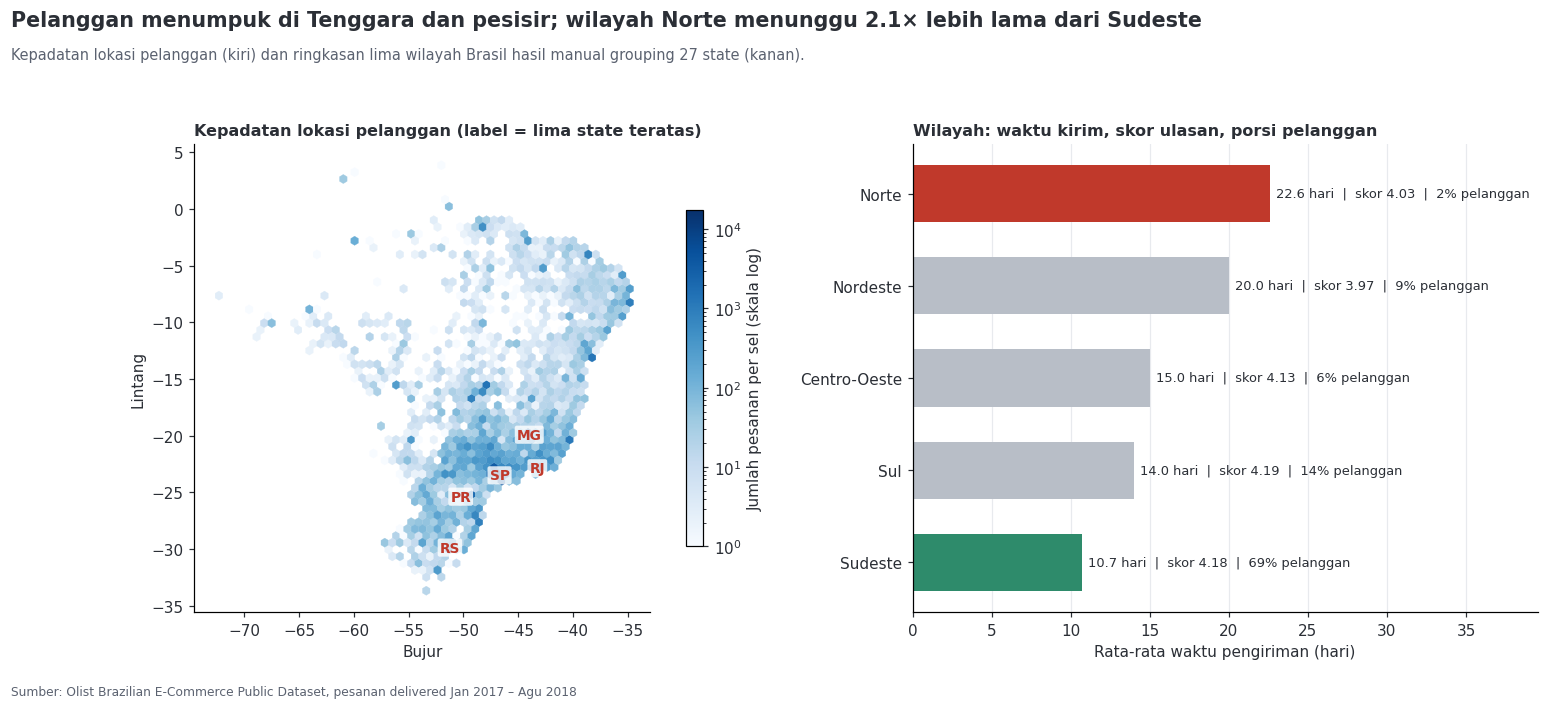

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})

# Left: density of customer locations (hexagonal bins, log scale)
ax = axes[0]
hb = ax.hexbin(geo_orders["customer_lng"], geo_orders["customer_lat"], gridsize=55, bins="log", cmap="Blues", mincnt=1, linewidths=0.2)
fig.colorbar(hb, ax=ax, shrink=0.72, label="Jumlah pesanan per sel (skala log)")
for st in state.index[:5]:
    ax.annotate(st, (state_xy.loc[st, "customer_lng"], state_xy.loc[st, "customer_lat"]), fontsize=9, fontweight="bold",
                color=RED, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))
ax.set_aspect(1 / np.cos(np.radians(-15)))
ax.set_xlabel("Bujur")
ax.set_ylabel("Lintang")
ax.set_title("Kepadatan lokasi pelanggan (label = lima state teratas)", fontsize=10.5)
ax.grid(False)

# Right: delivery time per region
ax = axes[1]
colors = [GREEN if i == 0 else RED if i == len(region_tab) - 1 else GRAY for i in range(len(region_tab))]
bars = ax.barh(region_tab.index, region_tab["delivery_days"], color=colors, height=0.62)
ax.bar_label(bars, labels=[f"{d:.1f} hari  |  skor {s:.2f}  |  {p:.0f}% pelanggan" for d, s, p in
                           zip(region_tab["delivery_days"], region_tab["review"], region_tab["cust_share"])], padding=4, fontsize=8.5)
ax.set_xlim(0, region_tab["delivery_days"].max() * 1.75)
ax.set_xlabel("Rata-rata waktu pengiriman (hari)")
ax.set_title("Wilayah: waktu kirim, skor ulasan, porsi pelanggan", fontsize=10.5)
ax.grid(axis="y", visible=False)

add_titles(fig,
           f"Pelanggan menumpuk di Tenggara dan pesisir; wilayah {slow_reg} menunggu {region_tab.loc[slow_reg, 'delivery_days'] / region_tab.loc[fast_reg, 'delivery_days']:.1f}× lebih lama dari {fast_reg}",
           "Kepadatan lokasi pelanggan (kiri) dan ringkasan lima wilayah Brasil hasil manual grouping 27 state (kanan).")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()

In [22]:
# Interactive map: one bubble per state; size = orders, color = mean delivery days
cmap = plt.get_cmap("YlOrRd")
norm = mcolors.Normalize(vmin=state["delivery_days"].min(), vmax=state["delivery_days"].max())
m = folium.Map(location=[-14.5, -51.0], zoom_start=4, tiles="OpenStreetMap", control_scale=True)
for st, row in state.join(state_xy).dropna(subset=["customer_lat"]).iterrows():
    popup = (f"<b>{st}</b> ({REGION[st]})<br>Pesanan: {idn(row['orders'])}<br>Pelanggan: {idn(row['customers'])}<br>"
             f"Revenue: R$ {idn(row['revenue'])}<br>Waktu kirim: {row['delivery_days']:.1f} hari<br>"
             f"Skor ulasan: {row['review']:.2f}<br>Terlambat: {row['late_pct']:.1f}%")
    folium.CircleMarker(
        location=[row["customer_lat"], row["customer_lng"]], radius=max(4, np.sqrt(row["orders"]) / 6), weight=1, color=INK,
        fill=True, fill_color=mcolors.to_hex(cmap(norm(row["delivery_days"]))), fill_opacity=0.8,
        tooltip=f"{st}: {idn(row['orders'])} pesanan, {row['delivery_days']:.1f} hari", popup=folium.Popup(popup, max_width=260),
    ).add_to(m)
m

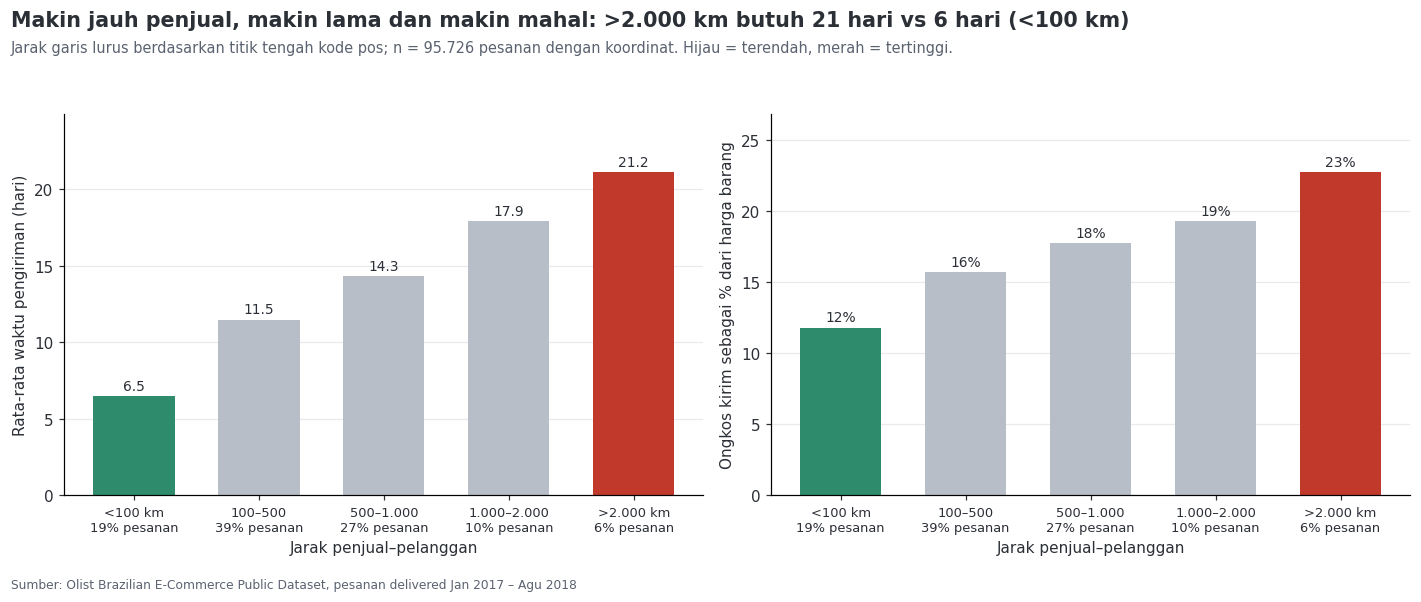

,orders,days,revenue,freight,review,freight_pct,order_pct
dist_bin,,,,,,,
<100 km,17780,6.48,"2,013,887.48","237,327.00",4.28,11.78,18.57
100–500,36956,11.48,"4,952,490.59","777,760.84",4.18,15.70,38.61
500–1.000,25696,14.30,"3,508,108.77","621,406.42",4.11,17.71,26.84
1.000–2.000,9703,17.95,"1,664,524.35","321,182.01",4.05,19.30,10.14
>2.000 km,5591,21.15,"979,414.49","222,765.25",3.97,22.74,5.84


In [23]:
# Seller-customer distance (haversine) in five classes
DIST_LABELS = ["<100 km", "100–500", "500–1.000", "1.000–2.000", ">2.000 km"]
orders_level["dist_bin"] = pd.cut(orders_level["distance_km"], bins=[0, 100, 500, 1000, 2000, np.inf], labels=DIST_LABELS, include_lowest=True)
by_dist = (orders_level.groupby("dist_bin", observed=True)
           .agg(orders=("order_id", "size"), days=("delivery_days", "mean"), revenue=("revenue", "sum"), freight=("freight", "sum"), review=("review_score", "mean")))
by_dist["freight_pct"] = by_dist["freight"] / by_dist["revenue"] * 100
by_dist["order_pct"] = by_dist["orders"] / by_dist["orders"].sum() * 100
r_dist_days = orders_level["distance_km"].corr(orders_level["delivery_days"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, col, label, fmt in [(axes[0], "days", "Rata-rata waktu pengiriman (hari)", "%.1f"),
                            (axes[1], "freight_pct", "Ongkos kirim sebagai % dari harga barang", "%.0f%%")]:
    colors = [GREEN if v == by_dist[col].min() else RED if v == by_dist[col].max() else GRAY for v in by_dist[col]]
    bars = ax.bar(range(len(by_dist)), by_dist[col], color=colors, width=0.65)
    ax.bar_label(bars, fmt=fmt, padding=2, fontsize=9)
    ax.set_xticks(range(len(by_dist)), [f"{l}\n{p:.0f}% pesanan" for l, p in zip(by_dist.index, by_dist["order_pct"])], fontsize=8.5)
    ax.set_ylim(0, by_dist[col].max() * 1.18)
    ax.set_ylabel(label)
    ax.set_xlabel("Jarak penjual–pelanggan")
    ax.grid(axis="x", visible=False)
add_titles(fig,
           f"Makin jauh penjual, makin lama dan makin mahal: >2.000 km butuh {by_dist['days'].iloc[-1]:.0f} hari vs {by_dist['days'].iloc[0]:.0f} hari (<100 km)",
           f"Jarak garis lurus berdasarkan titik tengah kode pos; n = {idn(by_dist['orders'].sum())} pesanan dengan koordinat. Hijau = terendah, merah = tertinggi.")
plt.tight_layout(rect=[0, 0.04, 1, 0.9])
plt.show()
by_dist.round(2)

**Insight (Geospatial dan Manual Grouping):**
- **Kepadatan:** pesanan menumpuk di koridor Tenggara–Selatan dan sepanjang pesisir; peta menunjukkan kluster sangat padat di sekitar SP, RJ, MG, sedangkan Norte hanya 1.9% dan Centro-Oeste 5.8% pelanggan.
- **Wilayah:** Sudeste paling cepat (10.7 hari, skor 4.18) dan Norte paling lambat (22.6 hari, skor 4.03, 10% terlambat). Sudeste menampung 69% pelanggan.
- **Jarak:** waktu pengiriman naik dari 6.5 hari (< 100 km) menjadi 21.2 hari (> 2.000 km), dan ongkos kirim naik dari 12% menjadi 23% dari harga barang (korelasi jarak–waktu kirim r = +0.39). Sebanyak 16% pesanan menempuh lebih dari 1.000 km.
- Skor ulasan pada kelas terjauh 3.97 vs 4.28 pada kelas terdekat: jarak ikut menekan kepuasan melalui waktu tunggu.

## Conclusion

- **Kesimpulan Pertanyaan 1 (kategori):** Health Beauty, Watches Gifts, Bed Bath Table, Sports Leisure, Computers Accessories adalah lima kategori teratas dan menyumbang **39.9%** dari total *revenue* R$ 13.179.778; 18 dari 73 kategori sudah mencapai 80% *revenue*. Lima kategori terbawah (Security And Services, Fashion Childrens Clothes, Cds Dvds Musicals, Home Comfort 2, Flowers) hanya 0.03%.
- **Kesimpulan Pertanyaan 2 (tren):** pesanan memuncak pada **Nov 2017** (7.288 pesanan) lalu bertahan pada 6.096–7.069 per bulan di 2018. Periode Jan–Agu 2018 dibanding Jan–Agu 2017: pesanan **+139.9%** dan *revenue* **+141.1%**, tetapi pertumbuhan YoY melambat dari +843% (Jan) menjadi +51% (Agu).
- **Kesimpulan Pertanyaan 3 (wilayah dan pengiriman):** pelanggan terbanyak di **SP** (41.9%); lima *state* teratas = 77.1%. Pengiriman terlama di **AM** (26.4 hari) dan skor terendah di **MA** (3.83). Pesanan terlambat (8.1%) dinilai 2.57 vs 4.29 untuk tepat waktu, selisih **1.73 poin**.
- **Analisis lanjutan:** (a) RFM: hanya 3.0% pelanggan membeli ulang; segmen *Berisiko bernilai tinggi* menyumbang 42% *revenue*. (b) Geospatial: wilayah Norte 2.1× lebih lambat daripada Sudeste; pengiriman > 2.000 km memakan 21 hari dan ongkir 23% dari harga barang.

### Rekomendasi (Action Items)
1. **Fokuskan stok, promosi, dan akuisisi penjual pada kategori teratas.** Health Beauty, Watches Gifts, Bed Bath Table memimpin dan lima kategori teratas = 40% *revenue*; tinjau kategori ekor panjang (lima terbawah hanya 0.03%) untuk digabung atau dijadikan bundel.
2. **Rancang kalender kampanye dan kapasitas logistik.** Siapkan armada dan stok sebelum Nov (puncak 7.288 pesanan) dan buat pemicu pertumbuhan baru karena 2018 mendatar di 6.096–7.069 pesanan per bulan dan pertumbuhan YoY sudah melambat menjadi +51% pada Agustus.
3. **Percepat pengiriman di wilayah lambat.** Prioritaskan mitra kurir dan pusat distribusi di Norte dan *state* terlama (AM, AL, PA); setiap keterlambatan memangkas skor ulasan sekitar 1.7 poin, sehingga akurasi estimasi dan notifikasi proaktif sama pentingnya dengan kecepatan.
4. **Dekatkan penjual ke pelanggan.** 16% pesanan menempuh > 1.000 km; rekrut penjual atau sediakan gudang di Nordeste/Norte/Centro-Oeste untuk memangkas waktu dan ongkir (ongkir 23% dari harga pada jarak terjauh).
5. **Bangun program retensi berbasis RFM.** Kampanye *win-back* (voucher terbatas waktu) untuk segmen *Berisiko bernilai tinggi* (22.2% pelanggan, 42% *revenue*), dan program loyalitas atau *follow-up* 30–60 hari untuk *Baru bernilai tinggi* agar tidak menjadi pembeli satu kali; turunkan 'hibernasi' lewat komunikasi berbiaya rendah.
6. **Lengkapi data berikutnya.** Tambahkan koordinat gudang penjual, mitra kurir, alasan pembatalan, dan data sesi pelanggan agar analisis logistik dan konversi lebih akurat.